<a href="https://colab.research.google.com/github/rakshansingh12/protein-function-classification-ml/blob/main/01_data_exploration_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Data exploration notebook ready")


Data exploration notebook ready


In [2]:
!pip install biopython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.4 MB/s eta 0:00:00


In [3]:
from Bio import SeqIO
import matplotlib.pyplot as plt
import re

In [9]:
enzyme_records = list(
    SeqIO.parse(
        "/content/uniprotkb_reviewed_true_AND_ec_2026_01_20.fasta",
        "fasta"
    )
)

non_enzyme_records = list(
    SeqIO.parse(
        "/content/uniprotkb_reviewed_true_AND_NOT_ec_2026_01_20.fasta",
        "fasta"
    )
)

print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))


/usr/local/lib/python3.12/dist-packages/Bio/SeqIO/FastaIO.py:202: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. This format allows for comments before the first sequence; lines starting with the ';' character anywhere in the file are also regarded as comment lines and are ignored.



Enzymes: 120731
Non-enzymes: 142244


In [10]:
enzyme_lengths = [len(r.seq) for r in enzyme_records]
non_enzyme_lengths = [len(r.seq) for r in non_enzyme_records]


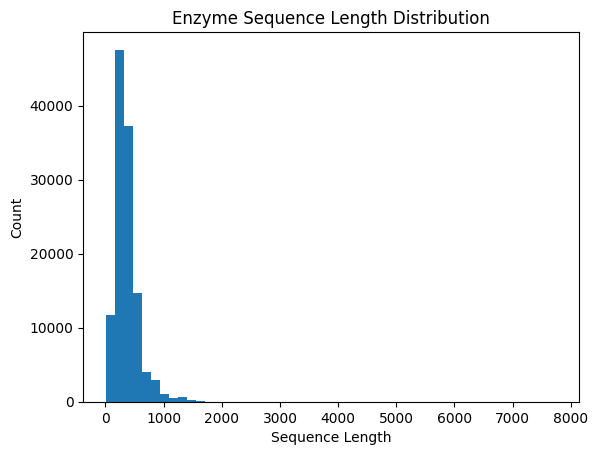

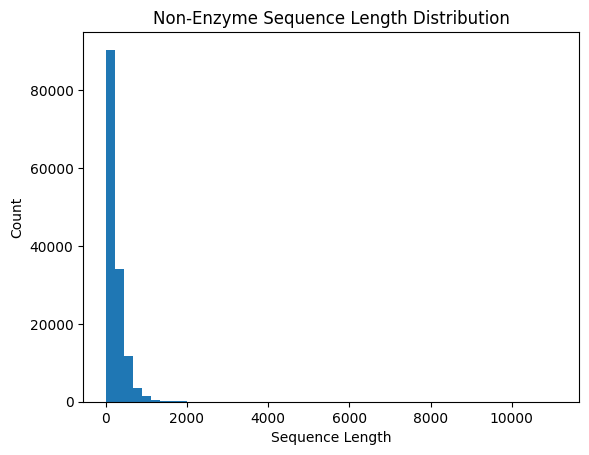

In [11]:
plt.hist(enzyme_lengths, bins=50)
plt.title("Enzyme Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()

plt.hist(non_enzyme_lengths, bins=50)
plt.title("Non-Enzyme Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.show()


majority of the sequences lie in the range 100-500. we will filter out the sequences with less than 50 AA as they can act as noise for out model.

In [12]:
def filter_short(records, min_len=50):
    return [r for r in records if len(r.seq) >= min_len]

enzyme_records = filter_short(enzyme_records)
non_enzyme_records = filter_short(non_enzyme_records)

print("After length filtering:")
print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))


After length filtering:
Enzymes: 120244
Non-enzymes: 135158


we have filtered the dataset

In [13]:
def has_ambiguous(seq):
    return bool(re.search(r"[XBZJU]", str(seq)))

enzyme_records = [r for r in enzyme_records if not has_ambiguous(r.seq)]
non_enzyme_records = [r for r in non_enzyme_records if not has_ambiguous(r.seq)]

print("After removing ambiguous sequences:")
print("Enzymes:", len(enzyme_records))
print("Non-enzymes:", len(non_enzyme_records))


After removing ambiguous sequences:
Enzymes: 120035
Non-enzymes: 134618


These are ambiguous or special symbols, not real, specific amino acids.
“The exact amino acid here is not confidently known.

In [14]:
n = min(len(enzyme_records), len(non_enzyme_records))

enzyme_records = enzyme_records[:n]
non_enzyme_records = non_enzyme_records[:n]

print("Final balanced dataset size per class:", n)


Final balanced dataset size per class: 120035


dataset is balanced by making the number of enzyme_records to the number of non_enzyme_records.

In [15]:
SeqIO.write(enzyme_records, "/content/enzymes_clean.fasta", "fasta")
SeqIO.write(non_enzyme_records, "/content/non_enzymes_clean.fasta", "fasta")

120035